In [16]:
%pip install librosa lightning jiwer evaluate transformers tensorboardX matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 45.6 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 50.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import torch
import random
import librosa
import numpy as np
import soundfile as sf
from torch.utils.data import DataLoader, Dataset, Subset
import lightning as L

In [3]:
torch.set_float32_matmul_precision('medium')

In [4]:
RANDOM = 42

In [5]:
# Download dataset

DATA_PATH = "data/"
TORONTO_PATH = DATA_PATH + "toronto/"

# !mkdir data
# !wget "https://drive.usercontent.google.com/download?id=1j9d91QqE7_WnOnmEmidtOG55tpmxQUeJ&confirm=t" -nc -O data/toronto.zip
# !unzip -q data/toronto.zip -d data/toronto

In [6]:
from typing import TypedDict


class AudioSample(TypedDict):
    waveform: np.ndarray
    sample_rate: int
    path: str
    label: str


class TorontoDataset(Dataset[AudioSample]):
    def __init__(self, prefix: str, resample: int | None = None) -> None:
        super().__init__()

        with open(os.path.join(prefix, "labels.jsonl"), "r") as f:
            raw_labels = json.load(f)

        dirs = [e.name for e in os.scandir(prefix) if e.is_dir()]
        items: list[tuple[str, str, str]] = []

        for dirname in dirs:
            for filename in os.listdir(os.path.join(prefix, dirname)):
                assert filename.endswith(".wav")

                path = os.path.join(dirname, filename)
                label = raw_labels[f"dataset/{dirname}/{filename}"]
                items.append((path, dirname, label))

        self.prefix = prefix
        self.items = items

        self.resample = resample

    @property
    def sources(self):
        return [v[1] for v in self.items]

    def __getitem__(self, idx: int) -> AudioSample:
        path, _, label = self.items[idx]

        waveform, sample_rate = sf.read(os.path.join(self.prefix, path))

        # Resample if needed
        if self.resample is not None and sample_rate != self.resample:
            waveform = librosa.resample(
                waveform, orig_sr=sample_rate, target_sr=self.resample
            )
            sample_rate = self.resample

        waveform = np.array(waveform, dtype=np.float32)
        assert waveform.ndim == 1

        return {
            "waveform": waveform,
            "sample_rate": sample_rate,
            "path": path,
            "label": label,
        }

    def __len__(self):
        return len(self.paths)


class WhisperDataModule(L.LightningDataModule):
    def __init__(
        self,
        dataset: TorontoDataset,
        processor,
        batch_size: int = 128,
        val_batch_size: int = 128,
        val_size: float = 0.2,
        num_workers: int = 1,
    ) -> None:
        super().__init__()

        self.dataset = dataset
        self.processor = processor
        self.val_size = val_size
        self.batch_size = batch_size
        self.val_batch_size = val_batch_size
        self.num_workers = num_workers

    def setup(self, stage: str) -> None:
        TEST_LINES = [
            "toronto_27",
            "toronto_46",
            "toronto_42",
            "toronto_37",
            "toronto_89",
            "toronto_43",
            "toronto_157",
            "toronto_9",
            "toronto_156",
            "toronto_7",
            "toronto_123",
            "toronto_54",
            "toronto_67",
            "toronto_62",
            "toronto_81",
            "toronto_134",
            "toronto_148",
            "toronto_21",
            "toronto_135",
            "toronto_166",
            "toronto_58",
        ]

        test_sources = TEST_LINES
        trainval_sources = list(set(self.dataset.sources) - set(test_sources))
        random.Random(RANDOM).shuffle(trainval_sources)
        val_sources = trainval_sources[: int(len(trainval_sources) * self.val_size)]
        train_sources = list(set(trainval_sources) - set(val_sources))

        def make_subset(dataset, sources):
            idx = np.where(np.isin(dataset.sources, sources))[0]
            return Subset(dataset, idx)

        self.train_dataset = make_subset(self.dataset, train_sources)
        self.val_dataset = make_subset(self.dataset, val_sources)
        self.test_dataset = make_subset(self.dataset, test_sources)

    def _collate(self, batch: list[AudioSample]):
        SR = 16_000
        assert all(sample["sample_rate"] == SR for sample in batch)

        input_features = self.processor.feature_extractor(
            [sample["waveform"] for sample in batch],
            sampling_rate=SR,
            return_tensors="pt",
            return_attention_mask=True,
        )

        labels = self.processor.tokenizer(
            [sample["label"] for sample in batch],
            return_tensors="pt",
            padding="longest",
            return_attention_mask=True,
        )
        LABEL_PAD_ID = -100
        labels = labels["input_ids"].masked_fill(
            labels.attention_mask.ne(1), LABEL_PAD_ID
        )

        assert (labels[:, 0] != self.processor.tokenizer.bos_token_id).all()

        return {
            "input_features": input_features["input_features"],
            "attention_mask": input_features["attention_mask"],
            "labels": labels,
        }

    def train_dataloader(self):
        return DataLoader(
            # torch.utils.data.Subset(self.train_dataset, list(range(100))),
            self.train_dataset,
            shuffle=True,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            prefetch_factor=4,
            collate_fn=self._collate,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.val_batch_size,
            num_workers=self.num_workers,
            collate_fn=self._collate,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.val_batch_size,
            num_workers=self.num_workers,
            collate_fn=self._collate,
        )

In [7]:
import evaluate


class WhisperModule(L.LightningModule):
    def __init__(self, model, processor, lr=1e-5):
        super().__init__()
        self.save_hyperparameters(ignore=["model", "processor"])

        self.model = model
        self.processor = processor

        self.wer = evaluate.load("wer")
        self.cer = evaluate.load("cer")

    def forward(self, input_features, attention_mask, labels=None):
        return self.model(
            input_features=input_features, attention_mask=attention_mask, labels=labels
        )

    def training_step(self, batch, batch_idx):
        output = self(batch["input_features"], batch["attention_mask"], batch["labels"])
        loss = output.loss
        self.log("train/loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        output = self(batch["input_features"], batch["attention_mask"], batch["labels"])
        loss = output.loss
        self.log("val/loss", loss, on_epoch=True)

        # WER
        generated_ids = self.model.generate(
            input_features=batch["input_features"],
            attention_mask=batch["attention_mask"],
        )

        transcriptions = self.processor.batch_decode(
            generated_ids, skip_special_tokens=True
        )

        labels = batch["labels"].clone()
        labels[labels == -100] = self.processor.tokenizer.pad_token_id
        references = self.processor.batch_decode(labels, skip_special_tokens=True)

        self.wer.add_batch(predictions=transcriptions, references=references)
        self.cer.add_batch(predictions=transcriptions, references=references)

    def test_step(self, batch, batch_idx):
        output = self(batch["input_features"], batch["attention_mask"], batch["labels"])
        loss = output.loss
        self.log("test/loss", loss, on_epoch=True)

        # WER
        generated_ids = self.model.generate(
            input_features=batch["input_features"],
            attention_mask=batch["attention_mask"],
        )

        transcriptions = self.processor.batch_decode(
            generated_ids, skip_special_tokens=True
        )

        labels = batch["labels"].clone()
        labels[labels == -100] = self.processor.tokenizer.pad_token_id
        references = self.processor.batch_decode(labels, skip_special_tokens=True)

        self.wer.add_batch(predictions=transcriptions, references=references)
        self.cer.add_batch(predictions=transcriptions, references=references)

        self.log("test/wer", self.wer.compute(), on_epoch=True)
        self.log("test/cer", self.cer.compute(), on_epoch=True)

    def on_validation_epoch_end(self):
        self.log("val/wer", self.wer.compute(), prog_bar=True)
        self.log("val/cer", self.cer.compute(), prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr)

In [8]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration

MODEL_NAME = 'openai/whisper-small'

processor = WhisperProcessor.from_pretrained(MODEL_NAME)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [9]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger

dataset = TorontoDataset(TORONTO_PATH, resample=16_000)
data_module = WhisperDataModule(
    dataset,
    processor,
    batch_size=24,
    val_size=0.2,
    num_workers=8,
    val_batch_size=50,
)

In [10]:
whisper_module = WhisperModule(
    model=model,
    processor=processor,
    lr=1e-4,
)
whisper_module.train()

# Callbacks
checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",
    filename="whisper-tiny-{epoch:02d}-{val/wer:.2f}",
    monitor="val/wer",
    mode="min",
    save_top_k=3,
)
early_stopping = EarlyStopping(monitor="val/wer", patience=3, mode="min")

# Logger
logger = TensorBoardLogger(save_dir="whisper")

# Trainer
trainer = L.Trainer(
    max_epochs=10,
    precision="16-mixed",
    accumulate_grad_batches=8,
    gradient_clip_val=1.0,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
    log_every_n_steps=10,
)

trainer.fit(whisper_module, datamodule=data_module)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/venv/main/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/venv/main/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ WhisperForConditionalGeneration │  241 M │ train │     0 │
└───┴───────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 241 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 350                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/venv/main/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits pr

`Trainer.fit` stopped: `max_epochs=10` reached.


In [11]:
trainer.test(whisper_module, datamodule=data_module)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/cer          │    0.1592618077993393     │
│         test/loss         │     0.849059522151947     │
│         test/wer          │    0.39833173155784607    │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.849059522151947,
  'test/wer': 0.39833173155784607,
  'test/cer': 0.1592618077993393}]

In [12]:
baseline_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

In [13]:
from tqdm import tqdm

def evaluate_model(model, dataloader) -> tuple[float, float]:
    wer = evaluate.load("wer")
    cer = evaluate.load("cer")

    for batch in tqdm(dataloader):
        generated_ids = model.generate(
            input_features=batch["input_features"].to(model.device),
            attention_mask=batch["attention_mask"].to(model.device),
        )

        transcriptions = processor.batch_decode(generated_ids, skip_special_tokens=True)

        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id
        references = processor.batch_decode(labels, skip_special_tokens=True)

        wer.add_batch(predictions=transcriptions, references=references)
        cer.add_batch(predictions=transcriptions, references=references)

    return wer.compute(), cer.compute()

In [14]:
device = "cuda"
model.to(device)
baseline_model.to(device)

with torch.no_grad():
    wer, cer = evaluate_model(model, data_module.test_dataloader())
    baseline_wer, baseline_cer = evaluate_model(
        baseline_model, data_module.test_dataloader()
    )

100%|██████████| 111/111 [04:49<00:00,  2.61s/it]


In [17]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "baseline": {"WER": baseline_wer, "CER": baseline_cer},
    "fine-tuned": {"WER": wer, "CER": cer},
}

df = pd.DataFrame(data)
df

,baseline,fine-tuned
WER,0.475804,0.398334
CER,0.245690,0.158533


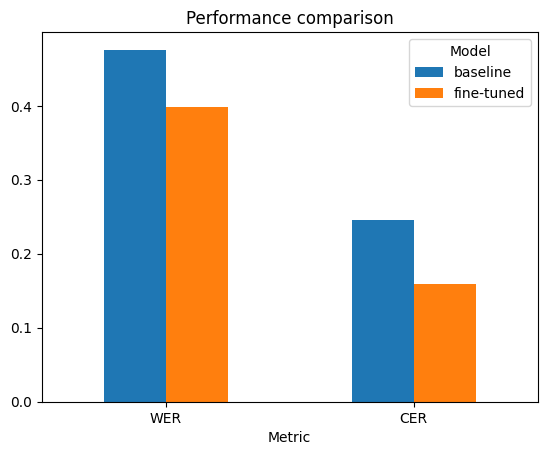

In [18]:
df.plot(kind="bar")
plt.title("Performance comparison")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.legend(title="Model")